In [17]:
#Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
import warnings
warnings.filterwarnings('ignore')

In [18]:
#Load the dataset
df = pd.read_csv('Malaria_Dataset.csv')
print("Shape:", df.shape)
print("\nFirst 5 rows:")
df.head()

Shape: (1622, 21)

First 5 rows:


,IP_Number,Age,Sex,Residence_Area,DOA,Discharge_Date,Fever,Headache,Abdominal_Pain,General_Body_Malaise,...,Vomiting,Confusion,Backache,Chest_Pain,Coughing,Joint_Pain,Primary_Code,Diagnosis_Type,Target,Risk_Score
0,14xxxx31,52,Female,Mangalore,31-10-2015 20:42,05-11-2015 05:16,0,0,0,1,...,0,0,1,0,0,0,B50.9,Mixed Malaria Infection,0,3
1,28xxxx34,75,Female,Shimoga,03-02-2015 23:28,13-02-2015 19:27,1,0,1,1,...,0,1,0,1,1,1,B50.9,Mixed Malaria Infection,1,11
2,96xxxx43,30,Female,Mangalore,15-11-2019 12:31,19-11-2019 14:31,1,1,1,1,...,0,1,1,1,0,1,B50.9,Mixed Malaria Infection,1,13
3,49xxxx87,89,Female,Mangalore,17-05-2017 17:50,23-05-2017 13:22,0,0,0,0,...,1,1,1,1,0,1,B54,Plasmodium vivax Malaria without complication,0,5
4,48xxxx10,62,Male,Shimoga,26-06-2015 15:29,27-06-2015 23:35,0,1,0,1,...,1,1,0,0,0,0,B51.0,Plasmodium falciparum Malaria without complica...,1,8


In [19]:
#Data Preprocessing
#Drop unnecessary columns (IDs, dates, diagnostic codes)
df = df.drop(columns=['IP_Number', 'DOA', 'Discharge_Date', 'Primary_Code', 'Diagnosis_Type'])

print("Remaining columns:", list(df.columns))
print("Shape after dropping:", df.shape)

Remaining columns: ['Age', 'Sex', 'Residence_Area', 'Fever', 'Headache', 'Abdominal_Pain', 'General_Body_Malaise', 'Dizziness', 'Vomiting', 'Confusion', 'Backache', 'Chest_Pain', 'Coughing', 'Joint_Pain', 'Target', 'Risk_Score']
Shape after dropping: (1622, 16)


#We drop those columns because IP_Number is an ID, DOA/Discharge_Date are date strings, and Primary_Code/Diagnosis_Type directly describe the diagnosis (would cause data leakage).

In [20]:
#Encode categorical variable (Sex)
le = LabelEncoder()
df['Sex'] = le.fit_transform(df['Sex'])  # Female=0, Male=1

print("Sex encoding:", dict(zip(le.classes_, le.transform(le.classes_))))
df.head()

Sex encoding: {'Female': np.int64(0), 'Male': np.int64(1)}


,Age,Sex,Residence_Area,Fever,Headache,Abdominal_Pain,General_Body_Malaise,Dizziness,Vomiting,Confusion,Backache,Chest_Pain,Coughing,Joint_Pain,Target,Risk_Score
0,52,0,Mangalore,0,0,0,1,0,0,0,1,0,0,0,0,3
1,75,0,Shimoga,1,0,1,1,1,0,1,0,1,1,1,1,11
2,30,0,Mangalore,1,1,1,1,0,0,1,1,1,0,1,1,13
3,89,0,Mangalore,0,0,0,0,1,1,1,1,1,0,1,0,5
4,62,1,Shimoga,0,1,0,1,0,1,1,0,0,0,0,1,8


In [21]:
#Encode Residence_Area
df['Residence_Area'] = le.fit_transform(df['Residence_Area'])

print("Residence Area encoding:", dict(zip(le.classes_, le.transform(le.classes_))))

Residence Area encoding: {'Chickmagalur': np.int64(0), 'Kasargod': np.int64(1), 'Mangalore': np.int64(2), 'Shimoga': np.int64(3), 'Udupi': np.int64(4)}


In [22]:
#Feature Scaling and Train-Test Split
#Separate features (X) and target (y)
X = df.drop(columns=['Target'])
y = df['Target']

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (1622, 15)
Target shape: (1622,)


In [23]:
#Train-Test Split (80/20)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Training set:", X_train.shape)
print("Testing set:", X_test.shape)

Training set: (1297, 15)
Testing set: (325, 15)


In [24]:
#Feature Scaling using StandardScaler
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [25]:
#Sigmoid function and SGD implementation

def sigmoid(z):
    return 1 / (1 + np.exp(-np.clip(z, -500, 500)))

def sgd_logistic_regression(X, y, learning_rate=0.01, epochs=100):
    m, n = X.shape
    weights = np.zeros(n)
    bias = 0
    losses = []
    
    y = y.values  # convert to numpy array
    
    for epoch in range(epochs):
        # Shuffle data for each epoch
        indices = np.random.permutation(m)
        X_shuffled = X[indices]
        y_shuffled = y[indices]
        
        for i in range(m):
            xi = X_shuffled[i]
            yi = y_shuffled[i]
            
            # Forward pass
            z = np.dot(xi, weights) + bias
            prediction = sigmoid(z)
            
            # Compute gradients
            error = prediction - yi
            dw = error * xi
            db = error
            
            # Update parameters
            weights -= learning_rate * dw
            bias -= learning_rate * db
        
        # Compute loss (binary cross-entropy) at end of each epoch
        z_all = np.dot(X, weights) + bias
        predictions_all = sigmoid(z_all)
        loss = -np.mean(y * np.log(predictions_all + 1e-8) + (1 - y) * np.log(1 - predictions_all + 1e-8))
        losses.append(loss)
        
        if (epoch + 1) % 10 == 0:
            print(f"Epoch {epoch+1}/{epochs} - Loss: {loss:.4f}")
    
    return weights, bias, losses

In [26]:
#Train the model
weights, bias, losses = sgd_logistic_regression(X_train, y_train, learning_rate=0.01, epochs=100)
print(f"\nFinal Loss: {losses[-1]:.4f}")

Epoch 10/100 - Loss: 0.0901
Epoch 20/100 - Loss: 0.0693
Epoch 30/100 - Loss: 0.0584
Epoch 40/100 - Loss: 0.0511
Epoch 50/100 - Loss: 0.0457
Epoch 60/100 - Loss: 0.0414
Epoch 70/100 - Loss: 0.0378
Epoch 80/100 - Loss: 0.0349
Epoch 90/100 - Loss: 0.0323
Epoch 100/100 - Loss: 0.0301

Final Loss: 0.0301


In [27]:
#Model Evaluation
#Make predictions on test set
z_test = np.dot(X_test, weights) + bias
y_pred_prob = sigmoid(z_test)
y_pred = (y_pred_prob >= 0.5).astype(int)

# Evaluation metrics
print("Model Evaluation\n")
print(f"Accuracy:  {accuracy_score(y_test, y_pred):.4f}")
print(f"Precision: {precision_score(y_test, y_pred):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred):.4f}")
print(f"F1 Score:  {f1_score(y_test, y_pred):.4f}")
print(f"\nClassification Report:\n")
print(classification_report(y_test, y_pred, target_names=['No Malaria', 'Malaria']))

Model Evaluation

Accuracy:  0.9969
Precision: 0.9957
Recall:    1.0000
F1 Score:  0.9979

Classification Report:

              precision    recall  f1-score   support

  No Malaria       1.00      0.99      0.99        92
     Malaria       1.00      1.00      1.00       233

    accuracy                           1.00       325
   macro avg       1.00      0.99      1.00       325
weighted avg       1.00      1.00      1.00       325



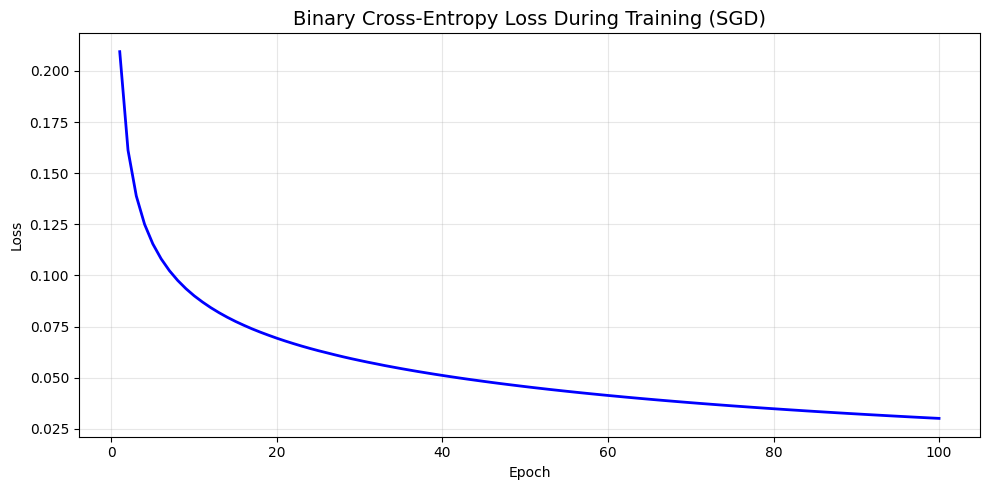

In [28]:
#Visualizations
#Plot 1: Loss evolution during training
plt.figure(figsize=(10, 5))
plt.plot(range(1, len(losses)+1), losses, color='blue', linewidth=2)
plt.title('Binary Cross-Entropy Loss During Training (SGD)', fontsize=14)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

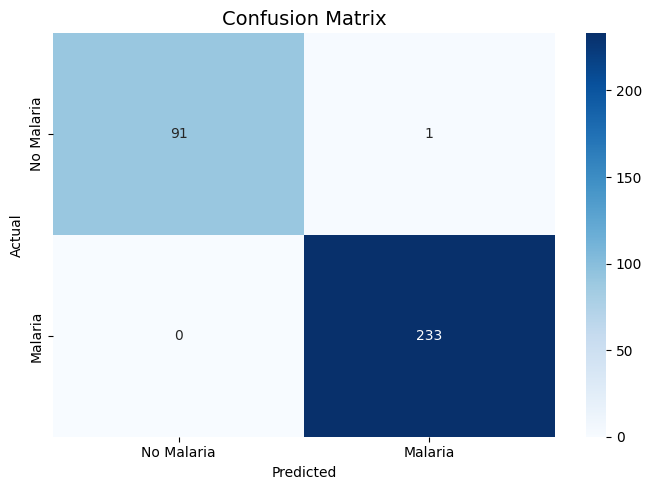

In [29]:
#Plot 2: Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Malaria', 'Malaria'],
            yticklabels=['No Malaria', 'Malaria'])
plt.title('Confusion Matrix', fontsize=14)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

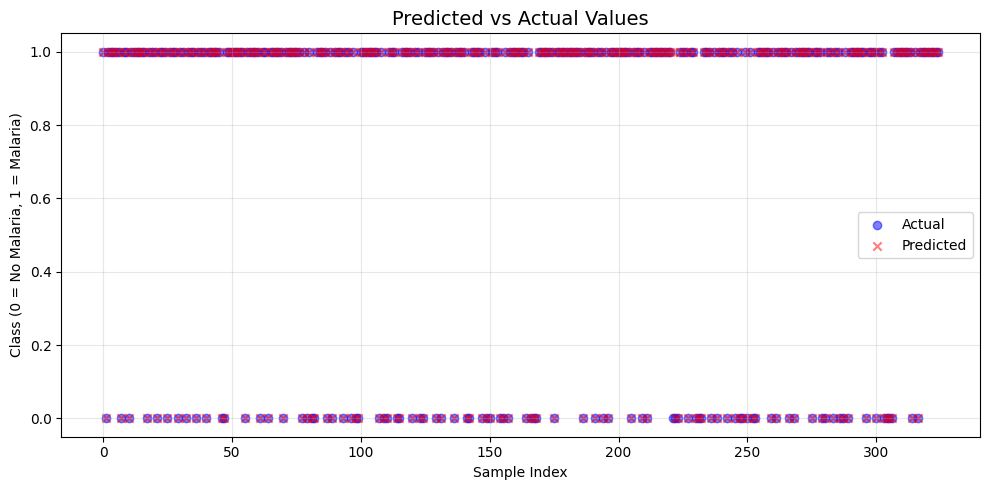

In [30]:
#Plot 3: Predicted vs Actual values
plt.figure(figsize=(10, 5))
x_axis = range(len(y_test))
plt.scatter(x_axis, y_test.values, color='blue', alpha=0.5, label='Actual', marker='o')
plt.scatter(x_axis, y_pred, color='red', alpha=0.5, label='Predicted', marker='x')
plt.title('Predicted vs Actual Values', fontsize=14)
plt.xlabel('Sample Index')
plt.ylabel('Class (0 = No Malaria, 1 = Malaria)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Project Report: Predicting Malaria Diagnosis Using SGD

## 1. Dataset Description

The dataset contains **1,622 patient records** with **21 features**, collected from the following areas:

- Mangalore  
- Shimoga  
- Chickmagalur  
- Udupi  
- Kasargod  

### Features:
- **Demographics:** Age, Sex, Residence Area  
- **Symptoms (0 = No, 1 = Yes):**  
  Fever, Headache, Abdominal Pain, General Body Malaise, Dizziness, Vomiting,  
  Confusion, Backache, Chest Pain, Coughing, Joint Pain  
- **Other:** Risk Score  
- **Target:**  
  - 1 = Malaria  
  - 0 = No Malaria  

### Class Distribution:
- Malaria: **1,167 (72%)**  
- No Malaria: **455 (28%)**

> Note: The dataset is imbalanced.

---

## 2. Data Preprocessing

- No missing values were found.
- Dropped columns:
  - `IP_Number` (ID)
  - `DOA`, `Discharge_Date` (dates)
  - `Primary_Code`, `Diagnosis_Type` (data leakage)

- Encoded categorical variables:
  - `Sex`, `Residence_Area` using Label Encoding

- Applied **StandardScaler** for normalization.

- Train-test split:
  - 80% training (1,297 samples)
  - 20% testing (325 samples)
  - `random_state = 42`

---

## 3. Model Implementation

Logistic Regression was implemented from scratch using **Stochastic Gradient Descent (SGD)**.

- Sigmoid function → converts outputs to probabilities  
- Loss function → Binary Cross-Entropy  
- SGD → updates weights per sample (with shuffling each epoch)

### Hyperparameters:
- Learning rate = 0.01  
- Epochs = 100  

> Loss decreased over epochs, showing good convergence.

---

## 4. Evaluation Results

| Metric    | Score |
|-----------|--------.....|
| Accuracy  |  0.9969     |
| Precision |  0.9957     |
| Recall    |  1.0000     |
| F1 Score  |  0.9979     |


---

## 5. Visualizations

- **Loss Curve:** Shows decreasing loss over epochs  
- **Confusion Matrix:** Shows classification performance (TP, TN, FP, FN)  
- **Predicted vs Actual:** Compares predictions with true labels  

---

## 6. Conclusion

The SGD-based Logistic Regression model successfully predicts malaria diagnosis.

- Model converged well (confirmed by loss curve)  
- Performs reasonably despite class imbalance  
- Confusion matrix shows prediction quality  

### Improvements:
- Tune learning rate and epochs  
- Handle imbalance (oversampling or class weights)  
- Try advanced models (Random Forest, Gradient Boosting)